# Portfolio Risk Analyser — RELIANCE & TCS
**Author:** Puneet Gupta 
**Data:** NSE via yfinance | 2023–2024  
**Methods:** Historical VaR (95% & 99%), Rolling Volatility, Correlation Analysis

## 1. Data Collection

In [13]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Download data
reliance = yf.download('RELIANCE.NS', start='2023-01-01', end='2024-12-31')
tcs = yf.download('TCS.NS', start='2023-01-01', end='2024-12-31')

# Combined closing prices
combined = pd.DataFrame({
    'RELIANCE': reliance['Close'].squeeze(),
    'TCS': tcs['Close'].squeeze()
})

# Daily returns
returns = combined.pct_change() * 100
returns = returns.dropna()

print(returns.shape)
print(returns.describe())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

(489, 2)
         RELIANCE         TCS
count  489.000000  489.000000
mean     0.013350    0.068403
std      1.282510    1.240803
min     -7.485140   -4.219151
25%     -0.780037   -0.589542
50%      0.027423    0.004651
75%      0.725150    0.680173
max      7.019207    6.632783


## 2. Returns & Portfolio Construction

In [14]:
weights = {'RELIANCE': 0.5, 'TCS': 0.5}

# Portfolio daily return = weighted sum of individual returns
returns['Portfolio'] = (returns['RELIANCE'] * weights['RELIANCE'] + 
                        returns['TCS'] * weights['TCS'])

print(returns.head())
print(f"\nPortfolio daily mean return: {returns['Portfolio'].mean():.3f}%")
print(f"Portfolio daily volatility: {returns['Portfolio'].std():.3f}%")

            RELIANCE       TCS  Portfolio
Date                                     
2023-01-03 -0.731785  1.529986   0.399101
2023-01-04 -1.505637  0.099668  -0.702985
2023-01-05 -0.178682 -0.107121  -0.142901
2023-01-06  0.908899 -3.006560  -1.048831
2023-01-09  2.361147  3.375327   2.868237

Portfolio daily mean return: 0.041%
Portfolio daily volatility: 0.997%


## 3. Risk Metrics - VaR

In [17]:
((0.5*1.2851)**2  + (0.5*1.240803)**2 +(2*0.5*0.5*1.2851*1.240803*.25))**0.5

0.9985429463046395

In [18]:
portfolio_value = 1000000  # ₹10 lakhs

var_95 = returns['Portfolio'].quantile(0.05)
var_99 = returns['Portfolio'].quantile(0.01)

print(f"1-day VaR at 95% confidence: {var_95:.2f}%  →  ₹{abs(var_95/100 * portfolio_value):,.0f}")
print(f"1-day VaR at 99% confidence: {var_99:.2f}%  →  ₹{abs(var_99/100 * portfolio_value):,.0f}")

1-day VaR at 95% confidence: -1.48%  →  ₹14,766
1-day VaR at 99% confidence: -2.51%  →  ₹25,096


## 4. Return Distribution

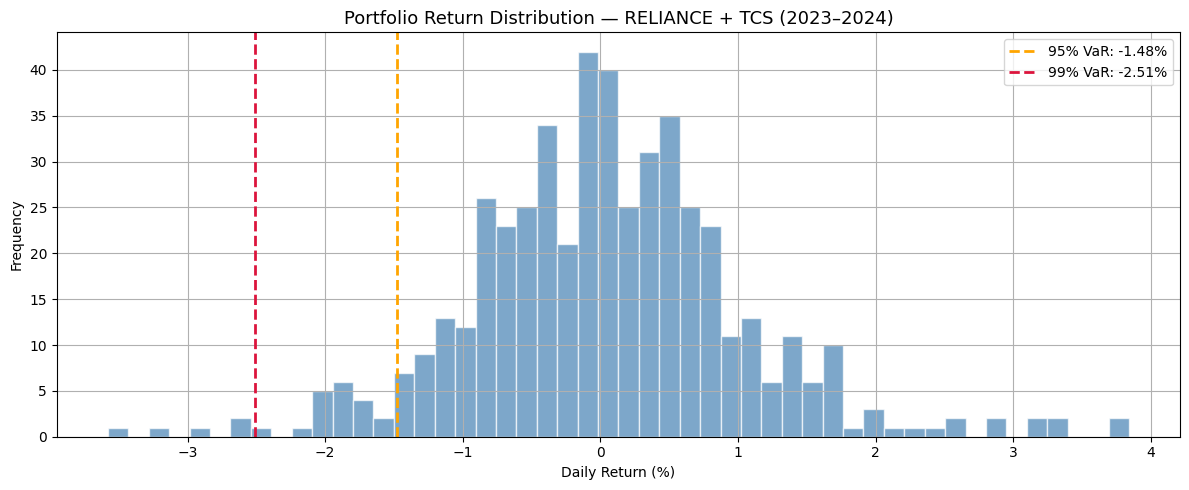

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))

returns['Portfolio'].hist(bins=50, ax=ax, color='steelblue', alpha=0.7, edgecolor='white')

ax.axvline(var_95, color='orange', linewidth=2, linestyle='--', label=f'95% VaR: {var_95:.2f}%')
ax.axvline(var_99, color='crimson', linewidth=2, linestyle='--', label=f'99% VaR: {var_99:.2f}%')

ax.set_title('Portfolio Return Distribution — RELIANCE + TCS (2023–2024)', fontsize=13)
ax.set_xlabel('Daily Return (%)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()